# EEP 567 Homework 2: Breaking CAPTCHAs End-to-End

In lab 3, we have successfully built a pipeline that automatically recognizes CAPTCHAs. So far, the recognition process requires manually identifying contours (and subsequently bounding boxes) around characters using expert rules, before performing classification on extracted character images. This inspires us for possible further improvement: can we use a single neural network to directly identify CAPTCHA characters from CAPTCHA image? In this homework, we will get rid of bounding box identification and build an end-to-end neural network model.

Like previous labs and homeworks, your task is to complete all missing code, improvement tasks and also answer questions related to the training process. When you have finished this homework, please submit this notebook as an archive with neural network model files (see "Submission" section for details).

## Before You Start

1. You can discuss on Slack if you have questions and want to seek help; however, please try your best to **limit the scope of your question** and **avoid asking directly for answers**. You should also **avoid copy-pasting answers and code** from others.
2. You are allowed to use AI assistants (such as ChatGPT or Google Bard) for help. In this case, you should **acknowledge your use of AI assistant** by providing its **name as well as how it helps you** to obtain your answer. Again, you **should not copy-paste from the response** of the AI assistant.
3. You can **optionally work on this homework with one other student of this course as a team**, but each of you needs to submit the homework individually. If you choose to form a group, please include the name of your teammate here: _(Name of your teammate)_.

## Pre-processing

First of all, make sure you have installed all dependencies needed for this homework. The list of depedencies is similar to lab 3, except that we will ditch OpenCV and `imutils`, and instead use PyTorch Vision (`torchvision`) for some of our preprocessing work:

In [5]:
%pip install matplotlib scikit-learn tqdm

Note: you may need to restart the kernel to use updated packages.


In [6]:
# If using Anaconda / Miniconda, install PyTorch and PyTorch Vision with:
# %conda install conda-forge::pytorch-gpu conda-forge::torchvision # (CPU and GPU support)
# %conda install conda-forge::pytorch conda-forge::torchvision # (CPU-only support)

# If using Pip, install PyTorch and PyTorch Vision with:
# %pip install torch torchvision
%pip install torchvision==0.20.1+cu121 --extra-index-url https://download.pytorch.org/whl/cu121
# When installing PyTorch with GPU support, refer to https://pytorch.org/get-started/locally/
# if your CUDA version differs from the default CUDA version of the current version PyTorch package.

Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu121
     ---------------------------------------- 0.0/6.1 MB ? eta -:--:--
     ---------------------------------------- 6.1/6.1 MB 53.2 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [5]:
import os

import torch
from torchvision.datasets.folder import IMG_EXTENSIONS
from torchvision.io import read_file, ImageReadMode, decode_image

if torch.cuda.is_available():
    print(f"Current GPU: {torch.cuda.get_device_name(0)}")
else:
    print("Using CPU")

Current GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [3]:
!tar -xf captcha-images.tar.xz

Once you are ready, we will start with data pre-processing step where we load all CAPTCHA images into memory. There are a few utilities in `torchvision` which can help us do the job:

In [7]:
# CAPTCHA images directory
CAPTCHA_IMAGES_DIR = "./captcha-images"

# CAPTCHA images
captcha_images = []
# CAPTCHA texts
captcha_texts = []

## [ TODO ]
# 1) Load all CAPTCHA images from `CAPTCHA_IMAGES_DIR` into `captcha_images`
#    (Hint: use `os.scandir` to iterate over directory entries and check file extensions with `IMG_EXTENSIONS`)
#    (Hint: use `torchvision.io.decode_image` to load images in grayscale mode)
#    (Note: your code should ignore non-image files)
# 2) Stack all CAPTCHA images into a PyTorch tensor
# 3) Load all CAPTCHA texts (filenames without extension) into `captcha_texts`
#    (Items in `captcha_images` and `captcha_texts` should match)
image_list = []
with os.scandir(CAPTCHA_IMAGES_DIR) as entries:
    for entry in entries:
        ext = os.path.splitext(entry.name)[1].lower()
        
        if entry.is_file() and ext in IMG_EXTENSIONS:
            raw_data = read_file(entry.path)
            img_tensor = decode_image(raw_data, mode=ImageReadMode.GRAY)
            img_tensor = img_tensor.to(torch.float32) / 255.0
            
            image_list.append(img_tensor)
            
            label_text = os.path.splitext(entry.name)[0]
            captcha_texts.append(label_text)

captcha_images = torch.stack(image_list)

assert isinstance(captcha_images, torch.Tensor), "`captcha_images` must be a PyTorch tensor!"
assert captcha_images.ndim==4, "`captcha_images` should be a 4D tensor!"
assert captcha_images.shape[1:]==(1, 24, 72), "`captcha_images` should have shape (n_images, 1, h, w)!"

assert len(captcha_images)==len(captcha_texts), \
    "`captcha_images` should have the same number of elements as `captcha_texts`!"
assert all(isinstance(text, str) and len(text)==4 for text in captcha_texts), \
    "all `captcha_texts` should be strings with four letters!"

print("Image loaded")

Image loaded


Then, we split all CAPTCHA images and texts into training-validation and test sets:

In [8]:
from sklearn.model_selection import train_test_split

# Training-validation-test split seed
TVT_SPLIT_SEED = 31528476

# Split dataset into training and test sets
captcha_images_tv, captcha_images_test, captcha_texts_tv, captcha_texts_test = train_test_split(
    captcha_images, captcha_texts, test_size=0.2, random_state=TVT_SPLIT_SEED
)

Next, we encode each character in the CAPTCHA text as class indices:

In [9]:
from sklearn.preprocessing import LabelEncoder
import hw2_util

# Label encoder
le = LabelEncoder()

## [ TODO ]
# 1) Flatten training-validation CAPTCHA texts into list of characters
#    (Hint: `hw2_util.flatten` can help you with that)
# 2) Fit and transform characters into class indices using `LabelEncoder`
# 3) Save number of classes (distinct characters) in `n_classes`
# 4) Convert class indices to PyTorch tensor and reshape as `texts_class_indices_tv`
#    (The shape of `texts_class_indices_tv` should be (n_images, 4))
all_characters = list(hw2_util.flatten(captcha_texts_tv)) # flatten: ['A', 'B', 'C', 'D', '1', '2', '3', '4', ...]
all_indices = le.fit_transform(all_characters)
n_classes = len(le.classes_)
texts_class_indices_tv = torch.tensor(all_indices).reshape(-1, 4) # all_indices is (n_images * 4)，so reshape(-1, 4) become 4 each row

assert isinstance(texts_class_indices_tv, torch.Tensor), "`texts_class_indices_tv` must be a PyTorch tensor!"
assert texts_class_indices_tv.ndim==2, "`texts_class_indices_tv` must have two dimensions!"
assert texts_class_indices_tv.shape==(len(captcha_texts_tv), 4), \
    "Shape of `texts_class_indices_tv` should be (n_images, 4)!"

print(f"Total distinct characters: {n_classes}")
print(f"Shape of label tensor: {texts_class_indices_tv.shape}")

Total distinct characters: 32
Shape of label tensor: torch.Size([908, 4])


Then, we further split training-validation set into two parts:

In [10]:
# Split training set further into training and validation sets
captcha_images_train, captcha_images_vali, texts_class_indices_train, texts_class_indices_vali = train_test_split(
    captcha_images_tv, texts_class_indices_tv, test_size=0.25, random_state=TVT_SPLIT_SEED
)

## Data Augmentation

The following step will be unique to this homework: we will perform **data augmentation** using PyTorch's [`transforms.Compose`](https://docs.pytorch.org/vision/main/generated/torchvision.transforms.Compose.html) and [`transforms.RandomAffine`](https://docs.pytorch.org/vision/main/generated/torchvision.transforms.RandomAffine.html). Here we will configure the `RandomAffine` transform to **apply the following random effects** to our CAPTCHAs:

* Random rotation (at most 5 degrees)
* Random horizontal and vertical shifting (at most 10%)
* Random shearing (at most 5 degrees)
* Random zooming in or out (at most 10%)

Besides, we will also **pre-process the image pixels** in the `RescaleInvertPixels` custom transform. Here we need to first **rescale the grayscale values** to $[0, 1]$ range and then **invert the grayscales**. We will chain the `RescaleInvertPixels` transform together with the `RandomAffine` transform using `Compose` to create a complete augmentation pipeline.

Below code will create such a transform pipeline, and preview its effects on a few sample CAPTCHAs:

Figure(2000x500)
Figure(2000x500)


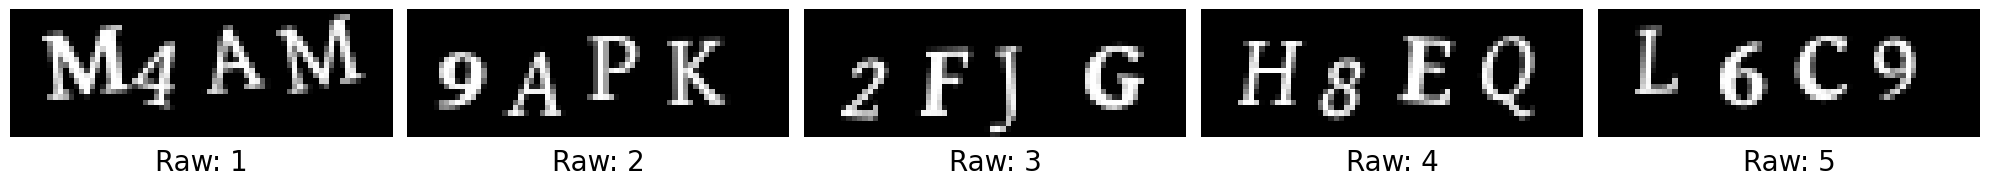

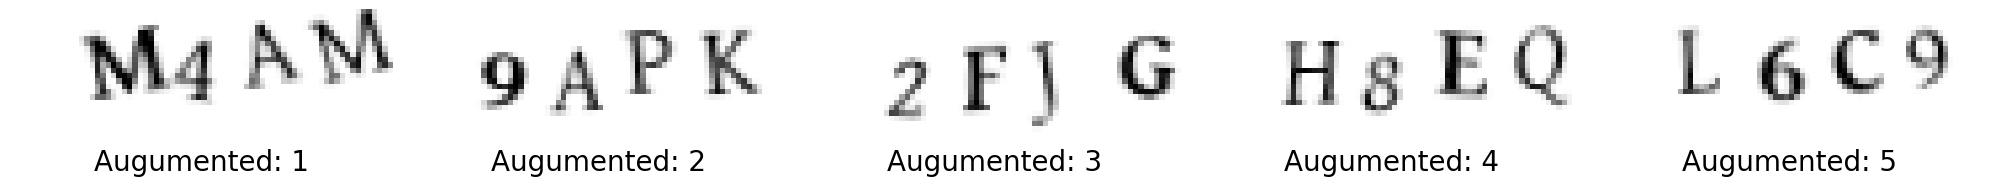

In [23]:
from torch import nn
from torchvision.transforms import Compose, InterpolationMode, RandomAffine

class RescaleInvertPixels(nn.Module):
    def forward(self, raw_image):
        ## [ TODO ]
        # 1) Rescale pixel grayscale values to [0, 1]
        if raw_image.max() > 1.0:
            rescaled = raw_image.to(torch.float32) / 255.0
        else:
            rescaled = raw_image.to(torch.float32)
        
        # 2) Invert the grayscales of the image (darker becomes lighter, and vice versa)
        inverted = 1.0 - rescaled
        
        # 3) Return modified grayscales
        return inverted

## [ TODO ]
# Create a transform pipeline using `Compose` with:
# 1) `RescaleInvertPixels()` for preprocessing
# 2) `RandomAffine` with the following random effects:
#    - Rotation: at most 5 degrees
#    - Horizontal and vertical shift: at most 10%
#    - Zooming: at most 10% (scale between 0.9 and 1.1)
#    - Shearing: at most 5 degrees
#    - Use `InterpolationMode.BILINEAR` for interpolation
#
# Choose parameters such that CAPTCHAs are moderately distorted but still recognizable.
captcha_transform = Compose([
    RescaleInvertPixels(),
    
    RandomAffine(
        degrees=5,                          # rotate
        translate=(0.1, 0.1),                # shift
        scale=(0.9, 1.1),                    # zoom
        shear=5,                            # shear
        interpolation=InterpolationMode.BILINEAR # interpolation
    )
])

# Select a few images for preview
preview_orig = captcha_images_train[:5]
# Generate a few transformed CAPTCHA images for preview
preview_trans = captcha_transform(preview_orig)

# Preview original and transformed CAPTCHAs
hw2_util.print_images(
    preview_orig.squeeze(-3),
    texts=[f"Raw: {i+1}" for i in range(5)]
)
hw2_util.print_images(
    preview_trans.squeeze(-3),
    texts=[f"Augumented: {i+1}" for i in range(5)]
)

Apart from the inversion of grayscale, you should be able to observe slight differences between original and transformed images. These transformed CAPTCHAs should still be easily recognizable, though.

## Training

From now on, we will shift our focus to the end-to-end neural network model. We assume our neural network model takes a bunch of CAPTCHA images (known as a batch) as input and outputs logits for each of the four character positions. In other words, if we have `n_classes` distinct characters in all CAPTCHAs, the output of our model would be a PyTorch tensor of shape `(batch_size, 4, n_classes)`. From each position's logits, we choose the character with the highest logit value (using the `argmax` operator), and we define a correct prediction as the one where all four characters are correctly predicted.

Our first task is to implement custom loss and accuracy functions for our task, since PyTorch's built-in functions expect different output formats. Both `pred_logits` (Raw model outputs) and `actual_class_indices` (Ground truth class indices) are batch tensors of shape `(batch_size, 4, n_classes)` and `(batch_size, 4)` respectively. Here we use PyTorch operations to compute our custom loss and accuracy metric:

In [24]:
from torch.nn import functional as f

def multi_char_loss(pred_logits, actual_class_indices):
    """ Compute the mean cross entropy loss of multiple CAPTCHA characters recognition. """
    return f.cross_entropy(pred_logits.flatten(0, 1), actual_class_indices.flatten())

def multi_char_acc(pred_logits, actual_class_indices):
    """ Compute the accuracy of multiple CAPTCHA characters recognition. """
    # Compute predicted class indices (most likely class / largest logits)
    pred_class_indices = pred_logits.argmax(-1)
    # Compute prediction accuracy for ALL four characters in a CAPTCHA, then average across samples
    return (pred_class_indices==actual_class_indices).all(-1).float().mean()

Next, we will complete `build_model` function which is responsible for building the neural network model. The neural network starts with several "convolution blocks" as usual, each of which contains a convolution layer for feature extraction and a max pooling layer for dimensionality reduction. The latter part of the network is however different from lab 3 in that **we replace regular fully-connected layers (implemented with linear layers) with "zone-wise" fully-connected layers (implemented with convolution layers)**. Below is the structure of our network:

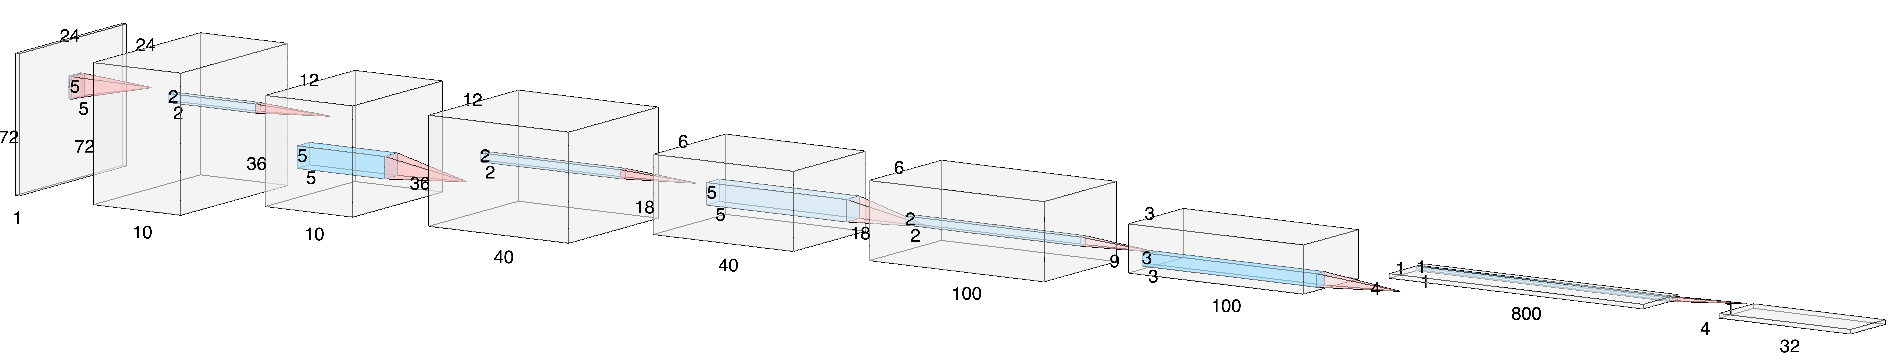

We also substitute the regular cross-entropy loss for our custom `multi_char_loss` and make use of our custom accuracy metric, `multi_char_acc`, due to the unique output format of our model.

In [25]:
from hw2_util import Transpose

def build_model(n_classes):
    """ Build the neural network model for CAPTCHA classification. """
    return nn.Sequential(
        # [ TODO ]
        # Complete the model architecture according to the specifications shown above and below:
        #
        # First convolution block: (*, 1, 24, 72) -Conv2d-> (*, 10, 24, 72) -ReLU-> (*, 10, 24, 72) -MaxPool2d-> (*, 10, 12, 36)
        # 1) Convolution layer: 1 input channel, 10 output channels, 5*5 kernel, padded to maintain same shape
        # 2) ReLU activation layer
        # 3) Max pooling layer: 2*2 kernel
        nn.Conv2d(1, 10, kernel_size=5, padding=2), # padding=2,  24x72
        nn.ReLU(),
        nn.MaxPool2d(2), #  12x36
        
        # Second convolution block: (*, 10, 12, 36) -Conv2d-> (*, 40, 12, 36) -ReLU-> (*, 40, 12, 36) -MaxPool2d-> (*, 40, 6, 18)
        nn.Conv2d(10, 40, kernel_size=5, padding=2), # padding=2  12x36
        nn.ReLU(),
        nn.MaxPool2d(2), # 6x18,
        
        # Third convolution block: (*, 40, 6, 18) -Conv2d-> (*, 100, 6, 18) -ReLU-> (*, 100, 6, 18) -MaxPool2d-> (*, 100, 3, 9)
        nn.Conv2d(40, 100, kernel_size=5, padding=2), # padding=2  6x18
        nn.ReLU(),
        nn.MaxPool2d(2), # 3x9,
        
        # First "zone-wise" fully-connected block: (*, 100, 3, 9) -Conv2d-> (*, 800, 1, 4) -ReLU-> (*, 800, 1, 4)
        # Convolution layer: 100 input channels, 800 output channels, 3*3 kernel, horizontal stride set to 2 to obtain 4 zones, no padding
        nn.Conv2d(100, 800, kernel_size=3, stride=(1, 2), padding=0),
        nn.ReLU(),
        
        # Second "zone-wise" fully-connected layer: (*, 800, 1, 4) -Conv2d-> (*, n_classes, 1, 4)
        # Convolution layer: `n_classes` channels, 1*1 kernel, no padding, used for dimensionality reduction
        nn.Conv2d(800, n_classes, kernel_size=1, padding=0),
        
        # Reshape and transpose dimensions: (*, n_classes, 1, 4) -Flatten-> (*, n_classes, 4) -`lab_3_helpers.Transpose`-> (*, 4, n_classes)
        nn.Flatten(start_dim=2),
        Transpose(1, 2)
    )

To facilitate efficient data loading and transformation, we will create a custom PyTorch [`Dataset`](https://docs.pytorch.org/docs/stable/data.html#torch.utils.data.Dataset) class called `CAPTCHADataset`. This class will handle loading CAPTCHA images and their corresponding labels, and apply the data augmentation transforms on-the-fly during training. By implementing the standard PyTorch [`Dataset`](https://docs.pytorch.org/docs/stable/data.html#torch.utils.data.Dataset) interface, we can leverage PyTorch's [`DataLoader`](https://docs.pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader) for efficient batch processing and parallel data loading:

In [28]:
from torch.utils.data import Dataset

class CAPTCHADataset(Dataset):
    def __init__(self, captcha_images, texts_features, captcha_transform):
        self.captcha_images = captcha_images
        self.texts_features = texts_features
        self.captcha_transform = captcha_transform

    def __len__(self):
        return len(self.captcha_images)

    def __getitem__(self, idx):
        captcha_image = self.captcha_transform(self.captcha_images[idx])
        text_features = self.texts_features[idx]

        return captcha_image, text_features

Finally, the `train_model` function implements the standard PyTorch training loop. For each epoch, it performs forward passes on batches from the training set, computes loss using `multi_char_loss`, backpropagates gradients, and updates model parameters. After each epoch, it evaluates the model on the validation set. Data augmentation is applied on-the-fly via the `CAPTCHADataset` during both training and validation.

In [29]:
from tqdm import tqdm
from torch.utils.data import DataLoader

def train_model(model, optimizer, dataset_train, dataset_vali, batch_size=32, n_epochs=50, device=None):
    # Detect device from model parameters if not provided
    device = device or next(iter(model.parameters())).device

    ## [ TODO ]
    # 1) Create training data loader from `dataset_train` with shuffling enabled
    # 2) Create validation data loader from `dataset_vali`
    # (Note: set the batch size for both loaders)
    loader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
    loader_vali = DataLoader(dataset_vali, batch_size=batch_size, shuffle=False)

    history = []
    
    print("Starting training ...")
    for i in range(n_epochs):
        # In every epoch, do training first ...
        loss_train = 0.
        acc_train = 0.
    
        print(f"Starting training epoch {i+1}/{n_epochs} ...")
        model.train()
        for captcha_images_batch, texts_class_indices_batch in tqdm(loader_train):
            ## [ TODO ]
            # Complete the training inner loop:
            #
            # 1) Move images and labels to the target device
            images = captcha_images_batch.to(device)
            labels = texts_class_indices_batch.to(device)            
            
            # 2) Perform forward pass to get logits
            logits = model(images)
            
            # 3) Compute loss using `multi_char_loss` and accuracy using `multi_char_acc`
            loss = multi_char_loss(logits, labels)
            acc = multi_char_acc(logits, labels)
            
            # 4) Perform backward propagation
            loss.backward()
            
            # 5) Update model parameters by taking an optimizer step
            optimizer.step()
            
            # 6) Clear model gradients
            optimizer.zero_grad()
            
            # 7) Accumulate loss and accuracy
            #    (Hint: Detach loss tensor before accumulation)
            #    (Hint: Move tensors to CPU for accumulation)
            loss_train += loss.detach().cpu()
            acc_train += acc.detach().cpu()
    
        loss_train = (loss_train/len(loader_train)).item()
        acc_train = (acc_train/len(loader_train)).item()
        # Report loss and metrics
        print(f"Ending training of epoch {i+1}/{n_epochs}: loss: {loss_train}, accuracy: {acc_train}")
    
        # Then evaluate the model
        loss_vali = 0.
        acc_vali = 0.
    
        # Put model in validation mode
        model.eval()
    
        print(f"Starting validation epoch {i+1}/{n_epochs} ...")
        with torch.no_grad():
            for captcha_images_batch, texts_class_indices_batch in tqdm(loader_vali):
                ## [ TODO ]
                # Complete the validation inner loop:
                #
                # 1) Move images and labels to the target device
                images = captcha_images_batch.to(device)
                labels = texts_class_indices_batch.to(device)
                
                # 2) Perform forward pass to get logits
                logits = model(images)
                
                # 3) Compute loss using `multi_char_loss` and accuracy using `multi_char_acc`
                v_loss = multi_char_loss(logits, labels)
                v_acc = multi_char_acc(logits, labels)
                
                # 4) Accumulate loss and accuracy (move tensors to CPU for accumulation)
                #    (Hint: Move tensors to CPU for accumulation)
                loss_vali += v_loss.cpu()
                acc_vali += v_acc.cpu()
    
        loss_vali = (loss_vali/len(loader_vali)).item()
        acc_vali = (acc_vali/len(loader_vali)).item()
        # Report loss and metrics
        print(f"Ending validation of epoch {i+1}/{n_epochs}: loss: {loss_vali}, accuracy: {acc_vali}")

        # Save epoch metrics
        history.append({
            "epoch": i+1,
            "loss_train": loss_train,
            "acc_train": acc_train,
            "loss_vali": loss_vali,
            "acc_vali": acc_vali
        })
    
        # Put model back in training mode
        model.train()

    return history

Ok, it's time to put everything together. We will build our model, train our model for some epochs and save it as `model-basic-params.pt`. For model training, you may adjust the number of epochs and / or batch size if necessary, to ensure that you achieve at least 80% of accuracy on the training set and at least 70% of accuracy on the validation set.

In [30]:
from torch.optim import AdamW

# Detect best PyTorch device
# (Prefer GPU devices such as CUDA or MPS, then fall back to CPU as last resort)
torch_device = hw2_util.get_torch_device()

# Build training and validation datasets
dataset_train = CAPTCHADataset(captcha_images_train, texts_class_indices_train, captcha_transform)
dataset_vali = CAPTCHADataset(captcha_images_vali, texts_class_indices_vali, captcha_transform)

# Build a basic end-to-end CAPTCHA model
model_basic = build_model(n_classes)
# Move model to PyTorch device
model_basic = model_basic.to(torch_device)
# Build an AdamW optimizer with model parameters
optimizer = AdamW(model_basic.parameters(), lr=0.001)

# Show model structure
print("Model structure:")
print(model_basic)
print()

# Train the basic model for 100 epochs
history_basic = train_model(model_basic, optimizer, dataset_train, dataset_vali)
# Save the basic model in file
torch.save(model_basic.state_dict(), "./model-basic-params.pt")

Model structure:
Sequential(
  (0): Conv2d(1, 10, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(10, 40, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Conv2d(40, 100, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (7): ReLU()
  (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (9): Conv2d(100, 800, kernel_size=(3, 3), stride=(1, 2))
  (10): ReLU()
  (11): Conv2d(800, 32, kernel_size=(1, 1), stride=(1, 1))
  (12): Flatten(start_dim=2, end_dim=-1)
  (13): Transpose(dim0=1, dim1=2)
)

Starting training ...
Starting training epoch 1/50 ...


100%|██████████████████████████████████████████████████████████████████████████████████| 22/22 [00:01<00:00, 14.68it/s]


Ending training of epoch 1/50: loss: 3.4126875400543213, accuracy: 0.0
Starting validation epoch 1/50 ...


100%|████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:00<00:00, 64.96it/s]


Ending validation of epoch 1/50: loss: 3.327965259552002, accuracy: 0.0
Starting training epoch 2/50 ...


...

Ending validation of epoch 49/50: loss: 0.19660690426826477, accuracy: 0.8216145634651184
Starting training epoch 50/50 ...


100%|██████████████████████████████████████████████████████████████████████████████████| 22/22 [00:00<00:00, 42.25it/s]


Ending training of epoch 50/50: loss: 0.12340584397315979, accuracy: 0.8963068127632141
Starting validation epoch 50/50 ...


100%|████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:00<00:00, 74.55it/s]

Ending validation of epoch 50/50: loss: 0.17254996299743652, accuracy: 0.87109375


## Evaluation

We have obtained a trained model as well as the training history during the previous stage. The training history contains the loss and accuracy of the nerual network as the training process proceeded. To show their trend during training, we plot these metrics for both training and validation set:

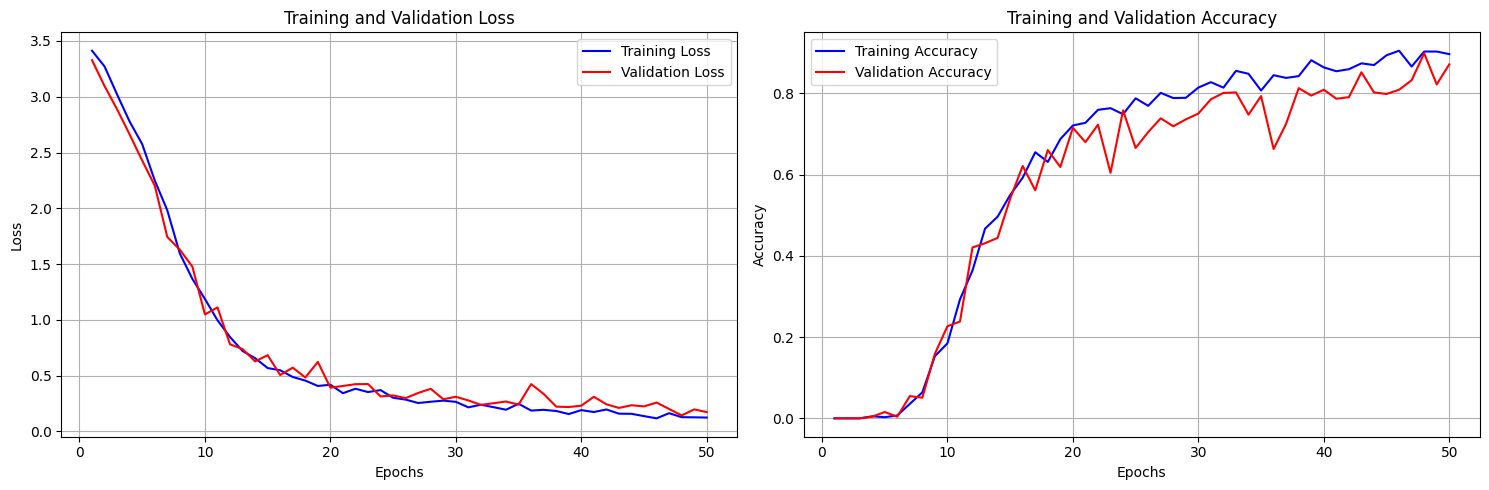

In [31]:
from matplotlib import pyplot as plt

## [ TODO ]
# 1) Plot the loss of the model during training for both training set and validation set.
#    (Hint: for history list of dicts, training loss is `history[epoch]["loss_train"]` and `history[epoch]["loss_vali"]`)
# 2) Plot the accuracy of the model during training for both training set and validation set.
#    (Hint: for history list of dicts, training accuracy is `history[epoch]["acc_train"]` and `history[epoch]["acc_vali"]`)
#    (Note: plot all curves for the same metric on the same graph for comparison)
epochs = [h["epoch"] for h in history_basic]
loss_train = [h["loss_train"] for h in history_basic]
loss_vali = [h["loss_vali"] for h in history_basic]
acc_train = [h["acc_train"] for h in history_basic]
acc_vali = [h["acc_vali"] for h in history_basic]

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, loss_train, label='Training Loss', color='blue')
plt.plot(epochs, loss_vali, label='Validation Loss', color='red')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, acc_train, label='Training Accuracy', color='blue')
plt.plot(epochs, acc_vali, label='Validation Accuracy', color='red')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Next, we evaluate our model end-to-end on the test set. Like training and validation set, we transform test set CAPTCHA images through data augmentation. We then predict the characters for these images and compare the predictions with ground truth. Similar to lab 3, we compute the accuracy of our model and show samples of correct and incorrect predictions:

In [44]:
def evaluate_model(model, le, dataset_eval, batch_size=32, n_epochs=5, n_display_samples=10, device=None):
    # Detect device from model parameters if not provided
    device = device or next(iter(model.parameters())).device

    ## [ TODO ]
    # Create evaluation data loader from `dataset_eval`
    # (Note: set the batch size)
    loader_eval = DataLoader(dataset_eval, batch_size=batch_size, shuffle=False)
    
    # Number of test samples and correct predictions
    n_test = n_correct = 0
    # Correct and incorrect samples
    correct_samples = []
    incorrect_samples = []

    # Put model in validation mode
    model.eval()
    
    for i in range(n_epochs):
        # In every epoch, do training first ...
        print(f"Starting evaluation epoch {i+1}/{n_epochs} ...")
        with torch.no_grad():
            for images_batch, texts_batch in tqdm(loader_eval):
                # Make a copy of images batch on target PyTorch device, while keeping original batch on CPU
                images_batch_device = images_batch.to(device)
                
                ## [ TODO ]
                # 1) Predict characters with neural network model
                logits = model(images_batch_device)
                
                # 2) Flatten and move predictions to CPU
                pred_indices = logits.argmax(-1).cpu().flatten().numpy()
                
                # 3) Decode predicted class indices back to characters using `LabelEncoder.inverse_transform`
                pred_chars = le.inverse_transform(pred_indices)
                
                # 4) Group every 4 characters together to form predicted CAPTCHAs
                #    (Hint: `hw2_util.group_every` can help with grouping)
                pred_texts = ["".join(group) for group in hw2_util.group_every(pred_chars, 4)]
                
                # 5) For each CAPTCHA, its prediction and actual text:
                #    - Update number of correct predictions
                #    - Collect `n_display_samples` correct samples of tuple (image, prediction) for review
                #    - Collect `n_display_samples` incorrect samples of tuple (image, prediction, actual) for review
                #      (Caution: DO NOT print ALL correct / incorrect images; this is slow and the output will be messy!)
                actual_texts = list(texts_batch)    
                    
                for img, pred, actual in zip(images_batch, pred_texts, actual_texts):
                    n_test += 1
                    if pred == actual:
                        n_correct += 1
                        if len(correct_samples) < n_display_samples:
                            correct_samples.append((img.squeeze(), actual))
                    else:
                        if len(incorrect_samples) < n_display_samples:
                            incorrect_samples.append((img.squeeze(), pred, actual))
        
        # Report loss and metrics
        print(f"Ending evaluation of epoch {i+1}/{n_epochs} ...")

    # Put model back in training mode
    model.train()
    
    # Show statistics
    print()
    print("# of test CAPTCHAs:", n_test)
    print("# correctly recognized:", n_correct)
    print("Accuracy:", n_correct/n_test, "\n")

    assert len(correct_samples)<=n_display_samples, \
        f"you should only display {n_display_samples} correct samples as examples!"
    assert len(incorrect_samples)<=n_display_samples, \
        f"you should only display {n_display_samples} incorrect samples as examples!"
    
    # Show all correct predictions
    hw2_util.print_images(
        hw2_util.unzip(correct_samples)[0],
        texts=[f"Correct: {actual}" for _, actual in correct_samples],
        n_rows=2
    )
    
    # Show all incorrect predictions
    hw2_util.print_images(
        hw2_util.unzip(incorrect_samples)[0],
        texts=[
            f"Prediction: {pred}\nActual: {actual}" \
            for _, pred, actual in incorrect_samples
        ],
        n_rows=2,
        fig_size=(20, 6),
        text_center=(0.5, -0.25)
    )

Now we run the evaluation process on the basic model:

Starting evaluation epoch 1/5 ...


100%|████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:00<00:00, 44.31it/s]


Ending evaluation of epoch 1/5 ...
Starting evaluation epoch 2/5 ...


100%|████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:00<00:00, 46.06it/s]


Ending evaluation of epoch 2/5 ...
Starting evaluation epoch 3/5 ...


...

Ending evaluation of epoch 3/5 ...
Starting evaluation epoch 4/5 ...


100%|████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:00<00:00, 45.53it/s]


Ending evaluation of epoch 4/5 ...
Starting evaluation epoch 5/5 ...


100%|████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:00<00:00, 42.82it/s]


Ending evaluation of epoch 5/5 ...

# of test CAPTCHAs: 1140
# correctly recognized: 957
Accuracy: 0.8394736842105263 

Figure(2000x500)
Figure(2000x600)


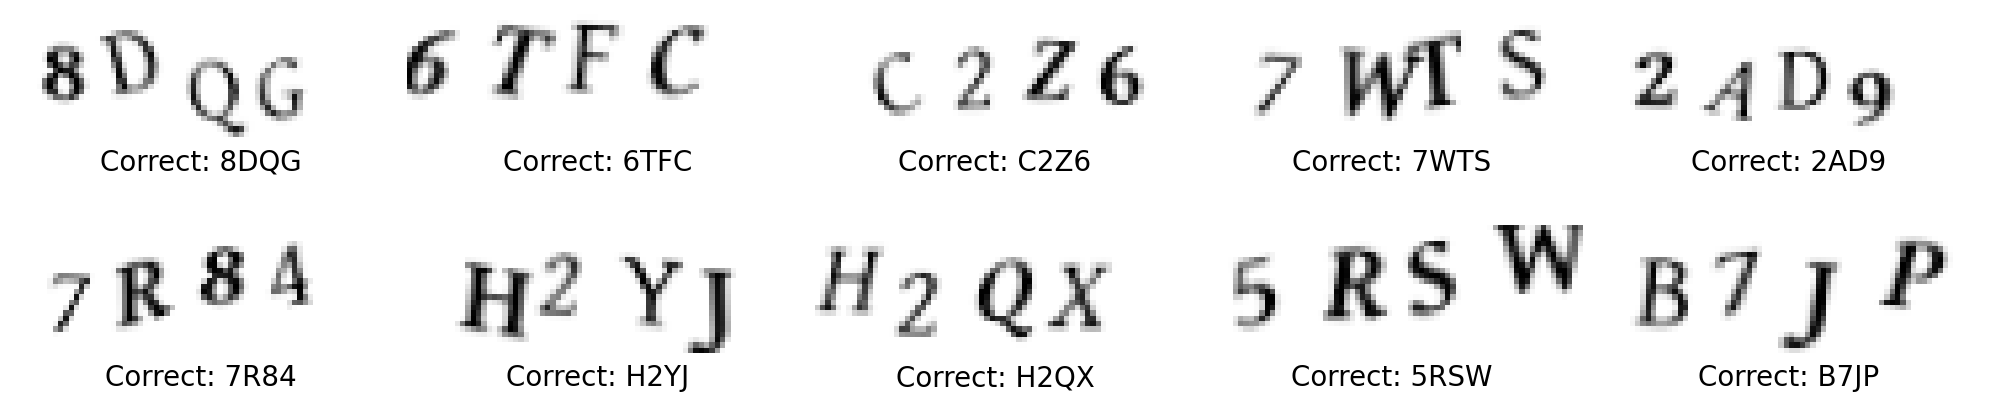

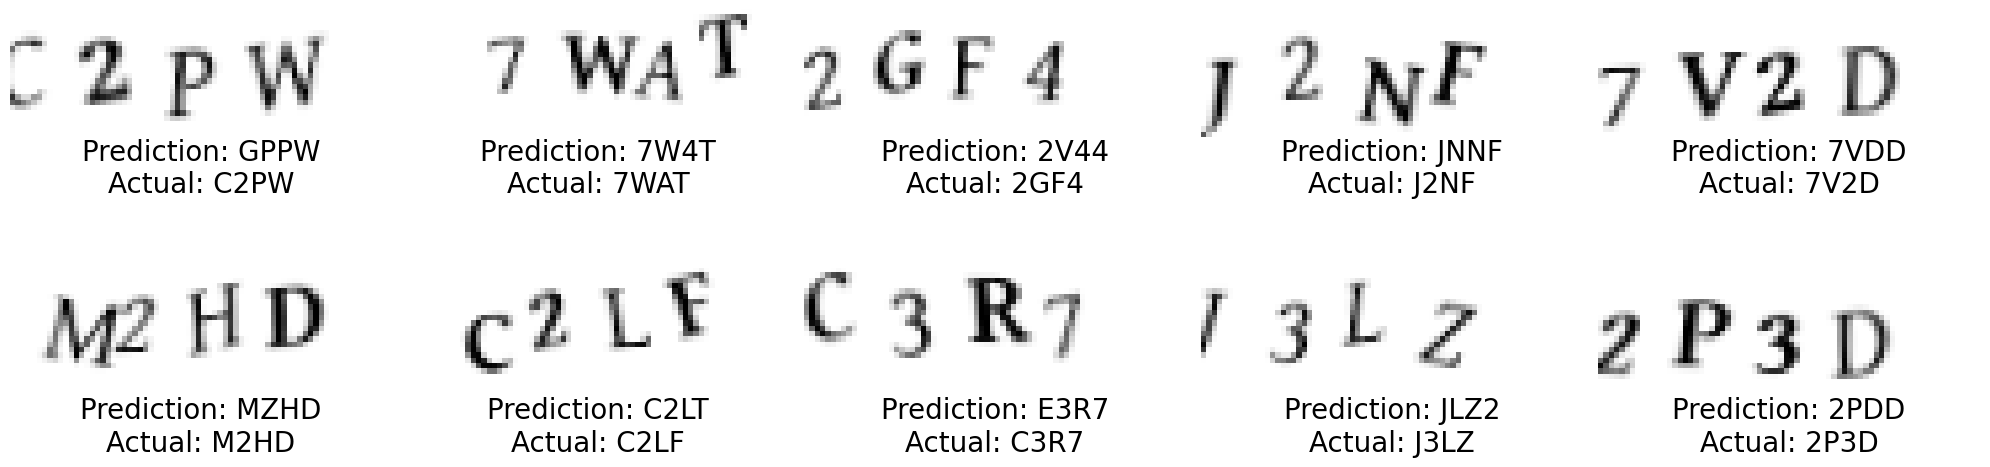

In [45]:
# Build evaluation dataset
dataset_eval = CAPTCHADataset(captcha_images_test, captcha_texts_test, captcha_transform)

# Evaluate the basic model
evaluate_model(model_basic, le, dataset_eval)

## Improvements (Optional; Not Graded)

Like homework 1, **you can optionally choose to work on two improvements to the neural network model**, and see if these modifications help with the accuracy. Please note that we won't grade your solutions for these questions, but we may give you feedbacks should you choose to complete them. We also encourage you to **reuse previous code and functions** as much as possible, and avoid repeating identicial code from previous part of this homework.

***

   Neural network models are susceptible to over-fitting problems due to their huge amount of free parameters. When neural network model overfits, it performs extremely well on the training set, but can easily fail when new samples are added. There are three possible approaches to mitigate the over-fitting issue:

  * Adding regularization (L1 and/or L2) to parameters of each linear or convolution layer.
  * Adding dropout layers (`torch.nn.Dropout`) to the model.
  * Adding batch normalization layers (`torch.nn.BatchNorm2d`) to the model.
  
Try one or a few of these approaches and compare their performance with the original model. Complete the following tasks by adding code and text cells  above and compare their performance with the original model. Complete the following tasks by adding code and text cells below:
  
  * Specify your choice of approaches and the details for each approach:
    - For regularization, this is the type of regularization and regularization factor for each convolution and linear layer.
    - For dropout layers, specify the number, position and dropout rate of all dropout layers.
    - For batch normalization layers, specify the number and position of all batch normalization layers.
  * Plot the loss and accuracy for both training and validation set. Think about what curves to put on the same plot.
    - One idea is to put the same metric of all four models (basic model and three improvement models) for the same set (e.g. training set) on the same plot. In this case, you will get four plots in the end.
    - You don't need to include plots as images in the notebook. Instead, just provide the code that can plot these curves.
  * Finally, report the accuracy of all three improvement models on the test set.

In [49]:
def build_model_improved(n_classes, use_dropout=False, use_bn=False):
    layers = []
    
    layers.append(nn.Conv2d(1, 10, kernel_size=5, padding=2))
    if use_bn: layers.append(nn.BatchNorm2d(10))
    layers.append(nn.ReLU())
    layers.append(nn.MaxPool2d(2))
    
    layers.append(nn.Conv2d(10, 40, kernel_size=5, padding=2))
    if use_bn: layers.append(nn.BatchNorm2d(40))
    layers.append(nn.ReLU())
    layers.append(nn.MaxPool2d(2))
    
    layers.append(nn.Conv2d(40, 100, kernel_size=5, padding=2))
    if use_bn: layers.append(nn.BatchNorm2d(100))
    layers.append(nn.ReLU())
    layers.append(nn.MaxPool2d(2))
    
    layers.append(nn.Conv2d(100, 800, kernel_size=3, stride=(1, 2)))
    if use_dropout: layers.append(nn.Dropout2d(p=0.5))
    layers.append(nn.ReLU())
    
    layers.append(nn.Conv2d(800, n_classes, kernel_size=1))
    
    layers.append(nn.Flatten(start_dim=2))
    layers.append(Transpose(1, 2))
    
    return nn.Sequential(*layers)

In [50]:
# 1. Basic Model
# 2. Dropout Model
model_dropout = build_model_improved(n_classes, use_dropout=True).to(torch_device)
optimizer_dropout = AdamW(model_dropout.parameters(), lr=0.001)
history_dropout = train_model(model_dropout, optimizer_dropout, dataset_train, dataset_vali)

# 3. BatchNorm Model
model_bn = build_model_improved(n_classes, use_bn=True).to(torch_device)
optimizer_bn = AdamW(model_bn.parameters(), lr=0.001)
history_bn = train_model(model_bn, optimizer_bn, dataset_train, dataset_vali)

# 4. L2 Regularization 
model_l2 = build_model_improved(n_classes).to(torch_device)
optimizer_l2 = AdamW(model_l2.parameters(), lr=0.001, weight_decay=1e-4)
history_l2 = train_model(model_l2, optimizer_l2, dataset_train, dataset_vali)

Starting training ...
Starting training epoch 1/50 ...


100%|██████████████████████████████████████████████████████████████████████████████████| 22/22 [00:00<00:00, 25.03it/s]


Ending training of epoch 1/50: loss: 3.4115118980407715, accuracy: 0.0
Starting validation epoch 1/50 ...


100%|████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:00<00:00, 88.72it/s]


Ending validation of epoch 1/50: loss: 3.355085849761963, accuracy: 0.0
Starting training epoch 2/50 ...


...

Ending validation of epoch 49/50: loss: 0.24767205119132996, accuracy: 0.7942708134651184
Starting training epoch 50/50 ...


100%|██████████████████████████████████████████████████████████████████████████████████| 22/22 [00:00<00:00, 52.49it/s]


Ending training of epoch 50/50: loss: 0.14807109534740448, accuracy: 0.8784722685813904
Starting validation epoch 50/50 ...


100%|████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:00<00:00, 81.71it/s]

Ending validation of epoch 50/50: loss: 0.19185031950473785, accuracy: 0.83984375


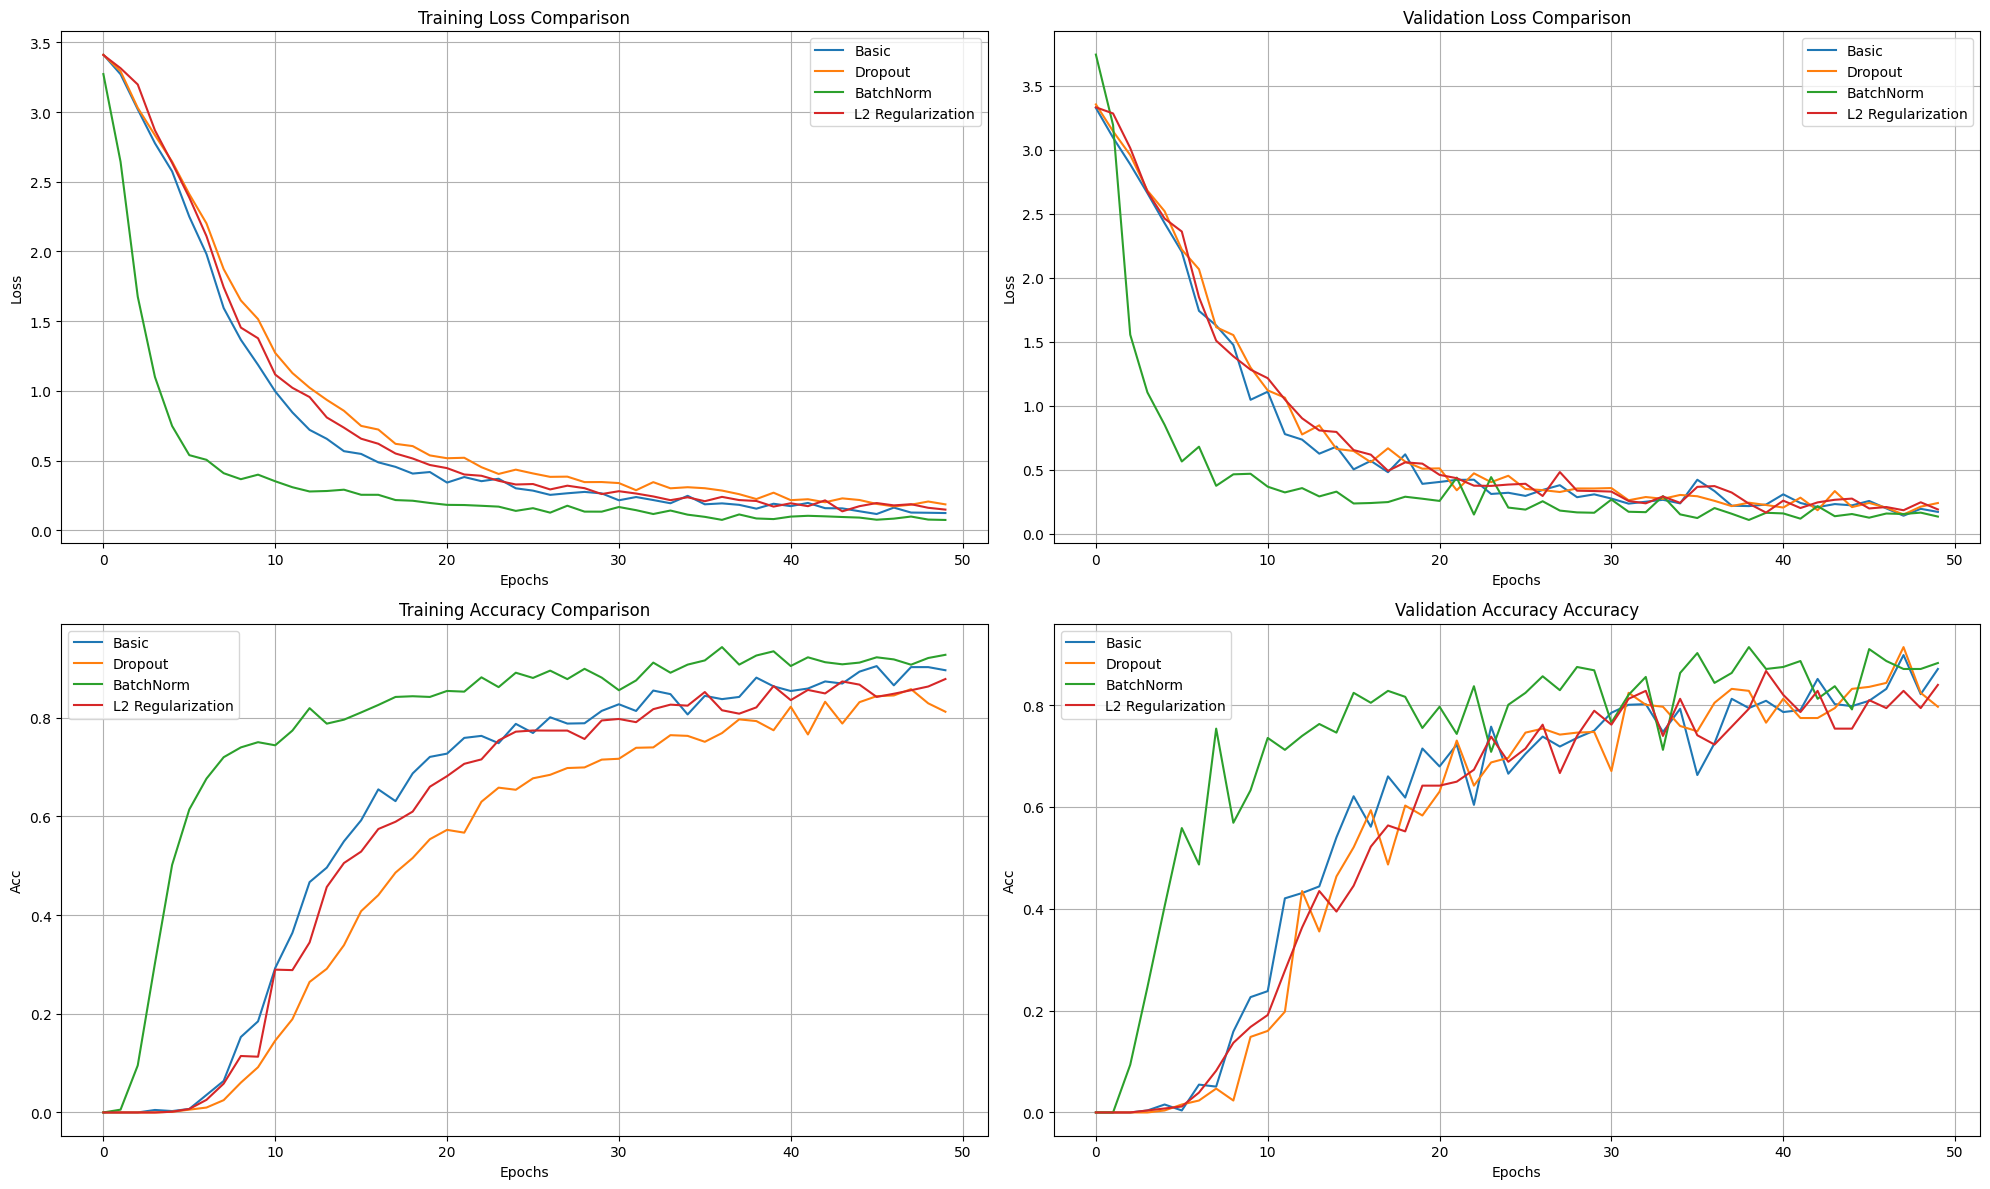

In [51]:
def plot_comparison(histories, names):
    metrics = ['loss_train', 'loss_vali', 'acc_train', 'acc_vali']
    titles = ['Training Loss Comparison', 'Validation Loss Comparison', 
              'Training Accuracy Comparison', 'Validation Accuracy Accuracy']
    
    plt.figure(figsize=(20, 12))
    
    for i, metric in enumerate(metrics):
        plt.subplot(2, 2, i+1)
        for h, name in zip(histories, names):
            values = [epoch_data[metric] for epoch_data in h]
            plt.plot(values, label=name)
        
        plt.title(titles[i])
        plt.xlabel('Epochs')
        plt.ylabel(metric.split('_')[0].capitalize())
        plt.legend()
        plt.grid(True)
    
    plt.tight_layout()
    plt.show()

all_histories = [history_basic, history_dropout, history_bn, history_l2]
all_names = ['Basic', 'Dropout', 'BatchNorm', 'L2 Regularization']
plot_comparison(all_histories, all_names)

## Questions

1. What is the purpose and benefits of data augmentation?
   - Hint: look at the size and complexity of the CAPTCHA dataset.

Answer: Data augmentation increases the effective size of the training set, makes the model more resilient against input perturbations and prevent model from overfitting the training data (e.g. focusing on very specific details of the data that is no longer valid with perturbation).

2. What is the purpose of 1\*1 convolution kernel?
   - Hint: Compare the 1\*1 convolution layer in this homework with fully-connected layers in lab 4.

Answer: 1\*1 convolution kernel is a common technique for reducing the number of channels of a 3D (or 2D) feature map, without changing the size of width and height (or length for 2D feature map) dimensions. 

3. **(Optional; Not Graded)** What is the purpose of dropout? Does it work on improving the convergence of training or on generalization? Give some reasons to support your idea.

Answer: Dropout is the technique of randomly zeroing out certain elements of weights or intermediate features. It's often used to prevent overfitting, when the neural network focuses too much on fragile details of the training data.

4. **(Optional; Not Graded)** What is the purpose of batch normalization? Does it work on improving the convergence of training or on generalization? Give some reasons to support your idea.

Answer: Batch normalization learns the mean and standard deviation of intermediate features given batches of inputs, and normalizes the data by re-centering and scaling features with learned metrics. It deals with the internal covariance shift problem, where aftering linear transformations and non-linear activations, the data distribution of the outputs differ from that of the inputs. It prevents the shifts from accumulating in deep neural networks and causing gradient vanishing or explosion problems.

1. What is the purpose and benefits of data augmentation?
   - Hint: look at the size and complexity of the CAPTCHA dataset.

Ans: Data augmentation increases dataset diversity by simulating real-world distortions like rotation and shifting to prevent the model from memorizing the training data. This improves generalization and robustness, allowing the neural network to identify figures directly from the image without bounding boxes.

2. What is the purpose of 1\*1 convolution kernel?
   - Hint: Compare the 1\*1 convolution layer in this homework with fully-connected layers in lab 4.

Ans: The 1*1 convolution is a dimensionality reduction that decreases the number of channels without chaning the width or height of the feature. 

5.	What is the purpose of max pooling layers in convolutional neural networks, like the ones we saw in this homework and lab 3?

Ans: The max pooling layer is a downsampling technique used to reduce the width and height dimensions of feature, such as shrinking a 24 X 72 input to 12 X 36. This process decreases the number of parameters to help reduse overfitting while ensuring the model gets the most dominant features and remains robust.


6.	In this homework, we use "zone-wise" fully-connected layers implemented with convolution layers, instead of flattening and fully-connected linear layers. What in your opinion are the rationales and advantages of this approach?

Ans: This approach preserves structure by mapping internal features to four distinct zones. It is  more parameter-efficient than traditional fully-connected layers, which helps resuse overfitting. This design enables the model to learn character sequences end-to-end without requiring manual segmentation or expert rules.

## Submission

When you have finished this homework, please submit an archive with this notebook (`homework-2-student.ipynb`) and the basic neural network model (`model-basic-params.pt`).

## References

1. PyTorch API reference: https://pytorch.org/docs/stable/index.html
2. PyTorch Neural Network Modules: https://pytorch.org/docs/stable/nn.html
3. Over-fitting: https://en.wikipedia.org/wiki/Overfitting
4. Residual neural network: https://en.wikipedia.org/wiki/Residual_neural_network
5. Residual blocks - Building blocks of ResNet: https://towardsdatascience.com/residual-blocks-building-blocks-of-resnet-fd90ca15d6ec